# Interpolation in one dimension

In [1]:
# initialization
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

## Prelude: interpolation for data alignment and imputation

Often times, answering a science question requires pulling together data from multiple sources. In analysis involving multiple data sources, **data alignment** can become an issue. For example, one may want to combine ship-based measurements with satellite data. In such case, the satellite data is often defined on a regular grid, and the ship would seldom be found precisely at a grid point.

One strategy to handle the alignment problem is **interpolation**. In basic terms, given a set of coordinates $(\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n)$ and a set of associated known values $(y_1, y_2, \ldots, y_n)$, interpolation provides a procedure to assign a specific value $y$ to any given coordinates $\mathbf{x}$ in the interior of $(\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n)$. In general, this procedure is required to produce $y = y_i$ when the coordinates $\mathbf{x}$ coincide with $\mathbf{x}_i$.

Another use of interpolation is **data imputation**. In many observational data, the measuring instrument is not always reliable and some data may be deemed bad or are missing. Assuming that the data is sufficiently clean, interpolation can be used to produce a synthetic value at which an observation is supposed to be taken.

There are many interpolation algorithms, each suitable for particular circumstances. In this course we will focus on one of the simplest interpolation strategy, namely **linear interpolation**

## Conceptual foundation of linear interpolation

You have essentially performed linear interpolation when you create a line plot by joining together discrete data points. As a concrete example, consider the plot of average (over time and longitude) sea surface temperature versus latitude, using data from the [World Ocean Atlas 2023](https://www.ncei.noaa.gov/access/world-ocean-atlas-2023/). The precise data we used for the plot below can be downloaded [here](https://github.com/OCEAN-215-2026/preclass/tree/main/week_09/data/woa23_all_o00_5d.nc).


In [2]:
woa23 = xr.open_dataset("data/woa23_decav_t00_5d.nc", decode_times=False)
sst = woa23["t_mn"].sel(depth=0, method="nearest").mean("lon").squeeze()
sst_lat = sst.coords["lat"].values
sst_val = sst.values

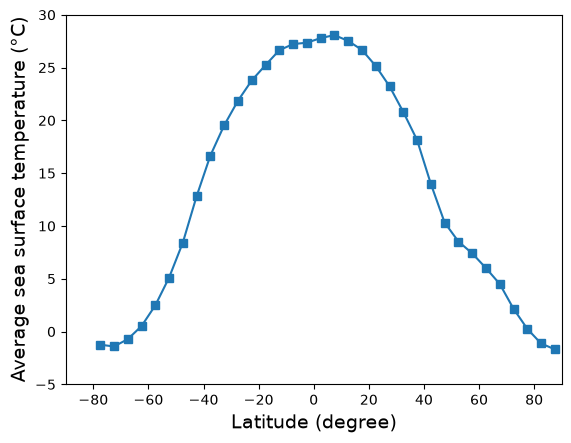

In [3]:
fig = plt.figure()
ax = fig.add_subplot()

ax.set_xlim(-90, 90)
ax.set_ylim(-5, 30)

ax.plot(sst_lat, sst_val, marker="s", color="tab:blue")
ax.set_xlabel("Latitude (degree)", fontsize=14)
ax.set_ylabel("Average sea surface temperature (°C)", fontsize=14)

plt.show(fig)

In the above plot, the actual data exists only at the location of the square markers, and the line plot is obtained by joining the markers using straight line segments. However, if we are to assign a temperature at a latitude that does not coincide with a marker, it is natural to read off the y coordinate at which the vertical line of the latitude intersect with the line plot. Doing so (as illustrated below, using the latitude of Portland, 45.5°N) precisely amount to performing a linear interpolation.

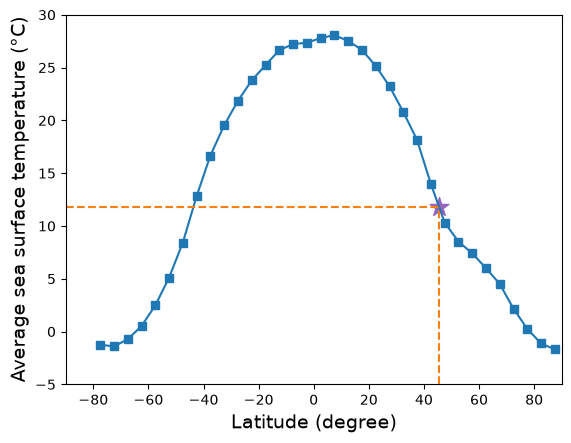

In [4]:
target_lat = 45.5
interp_sst = np.interp(target_lat, sst_lat, sst_val)

fig = plt.figure()
ax = fig.add_subplot()

ax.set_xlim(-90, 90)
ax.set_ylim(-5, 30)

ax.plot(sst_lat, sst_val, marker="s", color="tab:blue")
ax.set_xlabel("Latitude (degree)", fontsize=14)
ax.set_ylabel("Average sea surface temperature (°C)", fontsize=14)

ax.vlines(target_lat, -5, interp_sst, color="tab:orange", linestyle="--")
ax.hlines(interp_sst, -90, target_lat, color="tab:orange", linestyle="--")

ax.scatter(target_lat, interp_sst, marker='*', s=200, color='tab:purple')

plt.show(fig)

## Linear interpolation in python

Numpy, scipy, pandas, and xarray each provide its own interface(s) for interpolation. For definitiveness, we'll cover the numpy interface. We'll again use the average sea surface temperature versus latitude as our example. First let's generate the data used in the plot in the previous section: 

In [5]:
woa23 = xr.open_dataset("data/woa23_decav_t00_5d.nc", decode_times=False)
sst = woa23["t_mn"].sel(depth=0, method="nearest").mean("lon").squeeze()
sst_lat = sst.coords["lat"].values
sst_val = sst.values

In the above code, we load the gridded data from WOA23, subset it to surface and average over longitude (time is already averaged over at source data level). 

Now, to perform linear interpolation, we use the `np.interp()` function. It takes 3 required arguments: the x coordinates for which new y values are to be assigned, the x coordinates for which data are available, and the corresponding y coordinates of the data. Hence, to obtain the interpolated sea surface temperature at 45.5°N, we do:

In [14]:
target_lat = 45.5
interp_sst = np.interp(target_lat, sst_lat, sst_val)
print(interp_sst)

11.79416732788086


Putting that into a plot similar to that from the previous section,

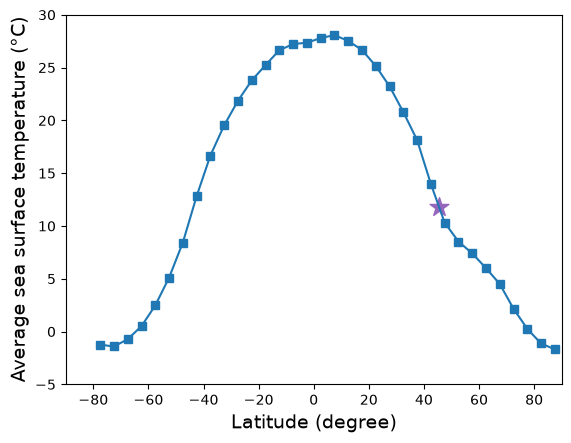

In [15]:
fig = plt.figure()
ax = fig.add_subplot()

ax.set_xlim(-90, 90)
ax.set_ylim(-5, 30)

ax.plot(sst_lat, sst_val, marker="s", color="tab:blue")
ax.set_xlabel("Latitude (degree)", fontsize=14)
ax.set_ylabel("Average sea surface temperature (°C)", fontsize=14)

ax.scatter(target_lat, interp_sst, marker='*', s=200, color='tab:purple')

plt.show(fig)

We note that the first argument of `np.interp()` can also be a numpy array. Thus, suppose we want to upsample the sea surface temperature data to 1° resolution, we may do:

In [16]:
new_lat = np.arange(-75, 75.1, 1)
new_sst = np.interp(new_lat, sst_lat, sst_val)
new_sst

array([-1.32450545, -1.35901053, -1.39351561, -1.3418685 , -1.2040692 ,
       -1.0662699 , -0.92847061, -0.79067131, -0.59779318, -0.34983622,
       -0.10187927,  0.14607769,  0.39403464,  0.71398948,  1.10594221,
        1.49789494,  1.88984767,  2.2818004 ,  2.74054401,  3.2660785 ,
        3.79161298,  4.31714747,  4.84268196,  5.43757443,  6.1018249 ,
        6.76607537,  7.43032584,  8.09457631,  8.86576586,  9.74389448,
       10.62202311, 11.50015173, 12.37828035, 13.20276222, 13.97359734,
       14.74443245, 15.51526756, 16.28610268, 16.95765095, 17.52991238,
       18.10217381, 18.67443523, 19.24669666, 19.76546497, 20.23074017,
       20.69601536, 21.16129055, 21.62656574, 22.0513195 , 22.43555183,
       22.81978416, 23.20401649, 23.58824883, 23.92596684, 24.21717052,
       24.50837421, 24.7995779 , 25.09078159, 25.37706451, 25.65842667,
       25.93978882, 26.22115097, 26.50251312, 26.70144844, 26.81795692,
       26.93446541, 27.05097389, 27.16748238, 27.23878536, 27.26

## Linear interpolation on time series

As with linear regression, in order to perform linear interpolation the x- and y-coordinates need to be pure number. Thus, when performing linear interpolation on a time series, we will first need to convert the x-coordinates into pure numbers.

As a concrete example, consider the monthly average seattle temperature (in °F) in the year 2025. Our data comes from the [Climate at a Glance City Time Series](https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/city/time-series/USW00024233/tavg/1/0/2024-2025) and the specific subset we use can be downloaded [here](https://github.com/OCEAN-215-2026/preclass/tree/main/week_09/data/Seattle_monthly_temperature.csv).

In [17]:
seattle_temp = pd.read_csv("data/Seattle_monthly_temperature.csv", skiprows=2)
seattle_temp

,Year,Month,Value
0,2025,1,39.2
1,2025,2,40.5
2,2025,3,47.1
3,2025,4,52.1
4,2025,5,57.0
5,2025,6,63.1
6,2025,7,67.9
7,2025,8,68.8
8,2025,9,64.1
9,2025,10,53.3


We may interpret the monthly average temperature at the _rolling mean_ temperature at the middle of the months. For example, the average April temperature may be interpreted as the 30-day average temperature around April 15. This allows us to think of the time series as being defined for every single day of the year and can speak of, e.g., the rolling mean temperature on April 5. There is no data on this particular date, but we can assign a synthetic value using linear interpolation.

To proceed, let's treat each monthly temperature as the rolling mean on the 15th day of each corresponding month, ignoring the slight inaccuracy introduced by uneven length of months.

In [18]:
dates = pd.to_datetime(seattle_temp["Year"].astype(str) + "-" + seattle_temp["Month"].astype(str) + "-15")
temps = seattle_temp["Value"]

To find the interpolated temperature on April 5, we convert the date into pure numbers like so:

In [19]:
dates_num = (dates - dates[0]) / np.timedelta64(1, 'D')

new_date = pd.to_datetime("2025-04-05")
new_date_num = (new_date - dates[0]) /  np.timedelta64(1, 'D')

Now we can perform interpolation using the numeric values thus obtained:

In [20]:
interp_temp = np.interp(new_date_num, dates_num, temps)

Plotting the results:

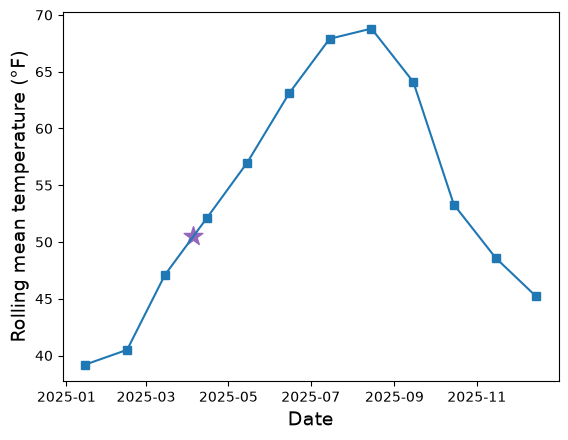

In [21]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(dates, temps, marker="s")
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Rolling mean temperature (°F)", fontsize=14)

ax.scatter(new_date, interp_temp, marker='*', s=200, color='tab:purple')

plt.show(fig)